# 01 - Análise Exploratória

Notebook para investigar distribuicoes, valores ausentes, outliers e relacoes iniciais com risco de credito.

In [2]:
import pandas as pd
import numpy as np

# loading data
df = pd.read_csv('../data/raw/application_train.csv')

print('Shape (rows, columns):', df.shape)

df.head()


Shape (rows, columns): (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Data types and null values
print('\n--- data types ---')
print(df.dtypes.value_counts())

print('\n--- Top 10 columns with the most null values ---')
null = df.isnull().sum().sort_values(ascending=False)
print(null[null > 0].head(10))

# Distribution of the target variable
print('\n--- Distribution of the target variable (0=Paid, 1=Delinquent)---')

print((df['TARGET'].value_counts(normalize=True) * 100).round(3)) 


--- data types ---
float64    65
int64      41
object     16
Name: count, dtype: int64

--- Top 10 columns with the most null values ---
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64

--- Distribution of the target variable (0=Paid, 1=Delinquent)---
TARGET
0    91.927
1     8.073
Name: proportion, dtype: float64


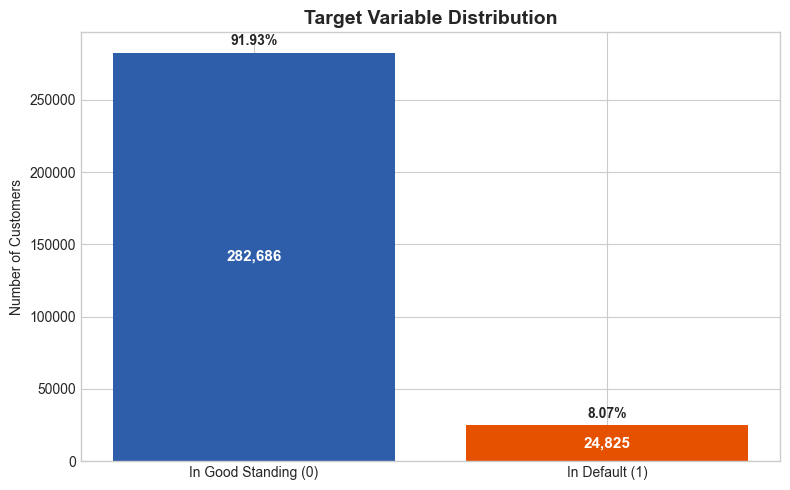

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Default visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# TARGET distribution plot
fig, ax = plt.subplots(figsize=(8, 5))
target_counts = df['TARGET'].value_counts()
colors = ['#2E5EAA', '#E65100']

# ensure we pass a NumPy array to matplotlib
counts = target_counts.to_numpy(dtype=float)

bars = ax.bar(['In Good Standing (0)', 'In Default (1)'], counts, color=colors)
ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')

# Add labels: absolute count inside, percentage above
for i, count in enumerate(counts):
    percentage = (count / len(df)) * 100
    
    # absolute count inside the bar
    ax.text(i, count/2, f'{int(count):,}', ha='center', va='center',
            color='white', fontweight='bold', fontsize=11)
    
    # percentage above the bar
    ax.text(i, count + (len(df)*0.01), f'{percentage:.2f}%', ha='center',
            va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/target_distribution.png', dpi=150)
plt.show()


# 02 - Análise de variáveis numéricas


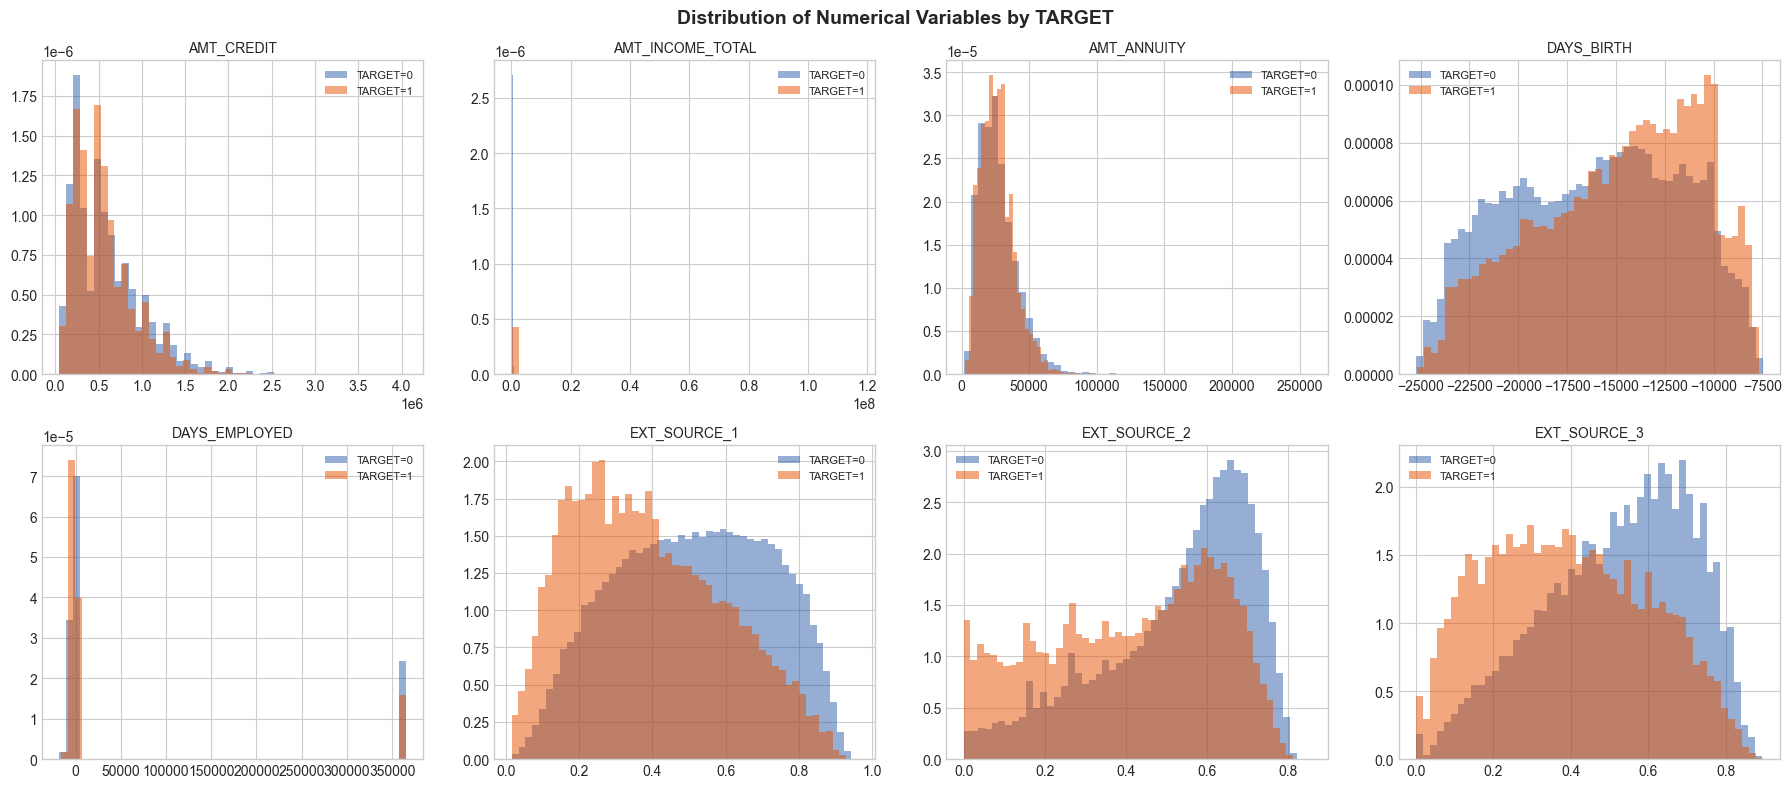

In [5]:
# Select the most relevant numerical variables
import matplotlib.pyplot as plt

num_yars = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1',
            'EXT_SOURCE_2', 'EXT_SOURCE_3']

# Breakdown by TARGET (In Good Standing vs. In Default)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(num_yars):
    for label, color in [{0, '#2E5EAA'}, {1, '#E65100'}]:
        subset = df[df['TARGET'] == label][var].dropna()
        axes[i].hist(subset, bins=50, alpha=0.5, color=color,
                     label=f'TARGET={label}', density=True)
    axes[i].set_title(var, fontsize=10)
    axes[i].legend(fontsize=8)
    
plt.suptitle('Distribution of Numerical Variables by TARGET', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observação geral das distribuições 

O gráfico compara a distribuição das principais variáveis numéricas entre clientes adimplentes (`TARGET=0`) e inadimplentes (`TARGET=1`). A maior parte das variáveis monetárias (`AMT_CREDIT`, `AMT_INCOME_TOTAL` e `AMT_ANNUITY`) apresenta bastante sobreposição entre os grupos, indicando que valor de renda, crédito ou parcela, isoladamente, não explica bem o risco de inadimplência.

As variáveis `EXT_SOURCE_1`, `EXT_SOURCE_2` e `EXT_SOURCE_3` mostram uma separação mais clara: clientes inadimplentes tendem a concentrar valores menores nessas fontes externas. Isso sugere que elas carregam informação relevante para o modelo preditivo e devem ser tratadas como features importantes na etapa de modelagem.

`DAYS_BIRTH` também traz sinal: como os valores são negativos, números mais próximos de zero representam clientes mais jovens, e o grupo inadimplente aparece relativamente mais concentrado nessa faixa. Já `DAYS_EMPLOYED` deve ser analisada com cuidado por causa de possíveis códigos/anomalias, mas ainda pode contribuir quando combinada com outras variáveis.

Para o projeto de risco de crédito e score alternativo, a principal conclusão é que o score não deve depender apenas de variáveis financeiras tradicionais. O modelo tende a ganhar poder explicativo ao combinar renda, crédito, idade/emprego e fontes externas, especialmente as `EXT_SOURCE`, que parecem capturar informações complementares sobre comportamento e perfil de risco.

# 03 - Análise de variáveis categóricas

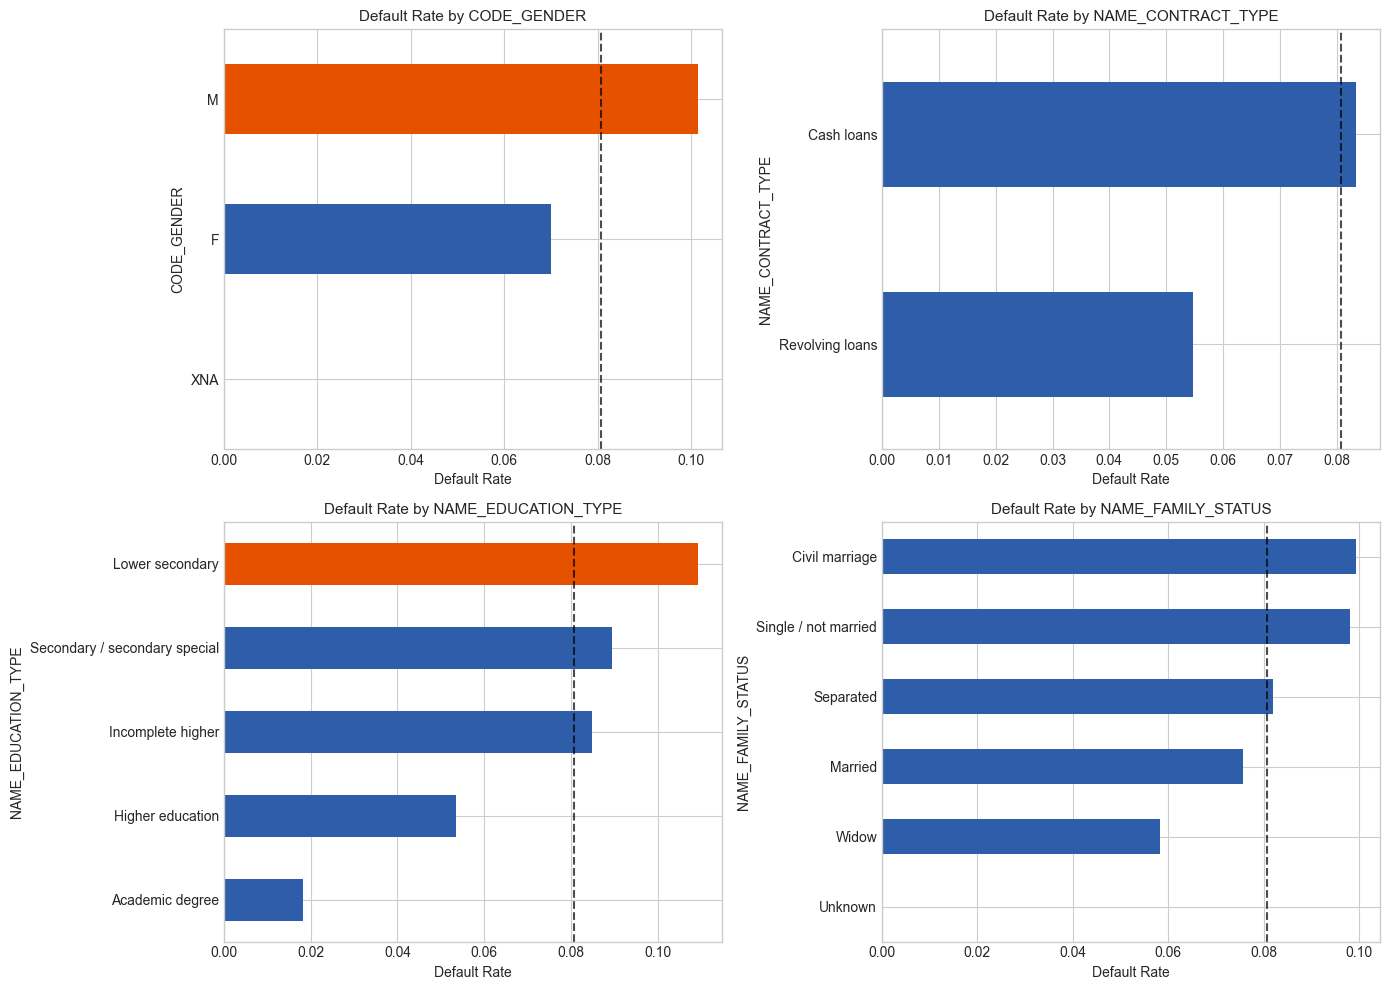

In [6]:
# Default Rate by Categorical Variable
cat_vars = ['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    # Calculate default rate for each category
    default_rate = df.groupby(var)['TARGET'].mean().sort_values(ascending=True)
    colors_bar = ['#E65100' if x > 0.1 else '#2E5EAA' 
                  for x in default_rate.values]
    default_rate.plot(kind='barh', ax=axes[i], color=colors_bar)
    axes[i].set_title(f'Default Rate by {var}', fontsize=11)
    axes[i].axvline(x=df['TARGET'].mean(), color='black', 
                    linestyle='--', alpha=0.7, label='Overall Default Rate')
    axes[i].set_xlabel('Default Rate')

plt.tight_layout()
plt.show()    
   

### Conclusão do gráfico

O gráfico evidencia que a taxa de inadimplência varia de forma relevante entre os grupos analisados. A linha tracejada representa a taxa média geral da base, aproximadamente 8,07%, e permite comparar quais categorias apresentam risco acima ou abaixo do comportamento médio da população.

Observa-se maior concentração de risco entre clientes do gênero masculino, contratos do tipo Cash loans, pessoas com menor nível de escolaridade e clientes classificados como Single / not married ou Civil marriage. Por outro lado, grupos como mulheres, clientes com Higher education, contratos Revolving loans e estado civil Married ou Widow apresentam taxas inferiores ou mais próximas da média geral.

Esses resultados indicam associações importantes para a etapa de modelagem, pois sugerem que algumas variáveis categóricas podem contribuir para diferenciar perfis de risco de crédito. No entanto, a interpretação deve considerar o volume de registros em cada categoria, especialmente grupos muito pequenos como XNA e Unknown, que não oferecem base estatística suficiente para conclusões robustas.